In [1]:
%env HF_HOME=/mnt/LLM
%env CUDA_VISIBLE_DEVICES=3
import torch
import transformers
import gymnasium
import numpy as np
import vizdoom
from typing import Sequence
from vizdoom import gymnasium_wrapper
from IPython.display import clear_output
import matplotlib.pyplot as plt
%matplotlib inline

model_name = "Qwen/Qwen3.6-35B-A3B"
processor = transformers.AutoProcessor.from_pretrained(model_name)
tokenizer = processor.tokenizer
model = transformers.AutoModelForMultimodalLM.from_pretrained(
    model_name, torch_dtype="auto", device_map="auto",
).train(False)
model.generation_config.temperature = 0.7

def get_logits_processor(model: transformers.PreTrainedModel, suppress_tokens: Sequence[int] = ()):
    """Create a transformers class that post-processes model logits for nucleus sampling, banned tokens, etc"""
    generation_config, model_kwargs = model._prepare_generation_config(model.generation_config)
    model._prepare_special_tokens(generation_config)
    device = next(model.parameters()).device
    return model._get_logits_processor(
        generation_config=generation_config,
        input_ids_seq_length=0,
        encoder_input_ids=None,
        prefix_allowed_tokens_fn=None,
        logits_processor=transformers.LogitsProcessorList([
            transformers.generation.logits_process.SuppressTokensLogitsProcessor(
                suppress_tokens, device=device)]),
        device=device,
        model_kwargs=model_kwargs
    )

env: HF_HOME=/mnt/LLM
env: CUDA_VISIBLE_DEVICES=3


[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/1026 [00:00<?, ?it/s]

# Non-thinking mode

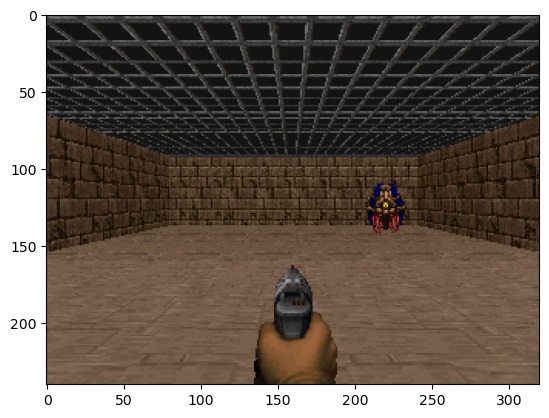

The enemy (a pink demon) is positioned to the right of the center of the screen, and thus to the right of the gun barrel. According to the aiming rules provided, if the enemy is to the right, you should move your point of view right to align them precisely above the barrel before firing. Therefore, the correct next action is to turn right.

[reasoning interrupted]
Probe top probabilities:
#0 [[right]]: 1.00000
#1 [[left]]: 0.00003
#2 [[move]]: 0.00000
#3 [[wait]]: 0.00000
#4 [[fire]]: 0.00000
SCORES: wait: 0.00000, fire: 0.00000, right: 1.00000, left: 0.00003
ACTION: right 2 r=-8.0, done=False


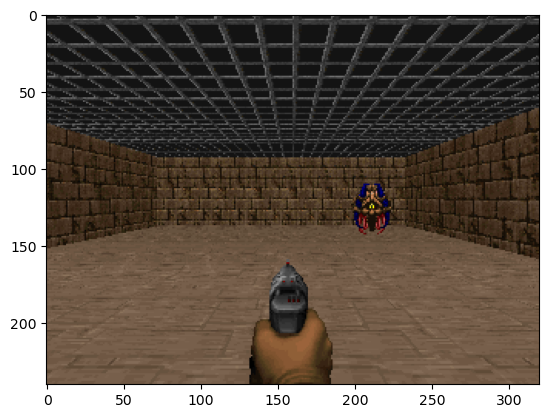

The enemy (a red, demon-like figure) is positioned slightly to the right of the center of the screen — specifically, it is not directly above the gun barrel but offset toward the right side. According to the aiming rules, if the enemy is to the right, you should move your point of view right to align the crosshair precisely over the gun barrel for a successful shot. Therefore, the correct next action is to adjust aim by moving right.

[reasoning interrupted]
Probe top probabilities:
#0 [[right]]: 1.00000
#1 [[left]]: 0.00005
#2 [[move]]: 0.00001
#3 [[fire]]: 0.00000
#4 [[wait]]: 0.00000
SCORES: wait: 0.00000, fire: 0.00000, right: 1.00000, left: 0.00005
ACTION: right 2 r=-8.0, done=False


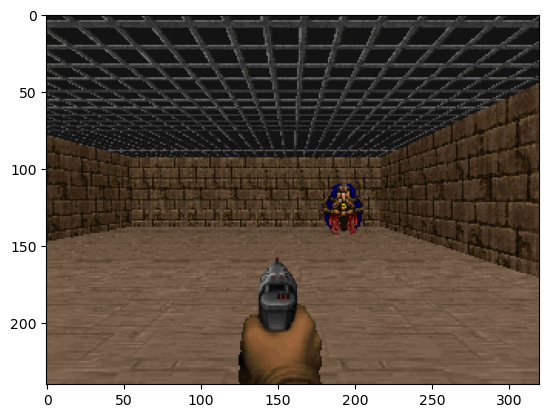

The enemy is positioned slightly to the right of the center of the screen, meaning the player’s point of view needs to adjust rightward to align the crosshair (implied by the gun barrel) with the enemy for a precise hit. Since the instruction states that the shot hits only if the enemy is precisely above the gun barrel at the center, and currently it is not — it’s offset to the right — the correct immediate action is to move right to reposition the aim.

[reasoning interrupted]
Probe top probabilities:
#0 [[right]]: 1.00000
#1 [[left]]: 0.00003
#2 [[move]]: 0.00001
#3 [[wait]]: 0.00000
#4 [[fire]]: 0.00000
SCORES: wait: 0.00000, fire: 0.00000, right: 1.00000, left: 0.00003
ACTION: right 2 r=-8.0, done=False


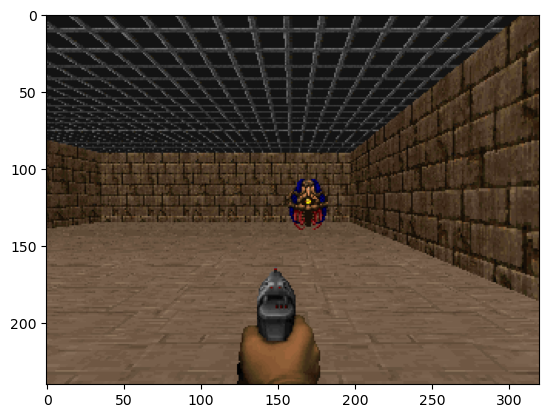

The enemy is positioned directly in the center of the screen, aligned precisely above the gun barrel, indicating that the player is already aimed correctly for a successful shot. There is no need to adjust the aim by moving left or right, and waiting would unnecessarily delay engagement. Therefore, the optimal action is to fire immediately while the targeting is accurate.

[reasoning interrupted]
Probe top probabilities:
#0 [[fire]]: 1.00000
#1 [[right]]: 0.00000
#2 [[Fire]]: 0.00000
#3 [[ fire]]: 0.00000
#4 [[f]]: 0.00000
SCORES: wait: 0.00000, fire: 1.00000, right: 0.00000, left: 0.00000
ACTION: fire 1 r=95.0, done=True


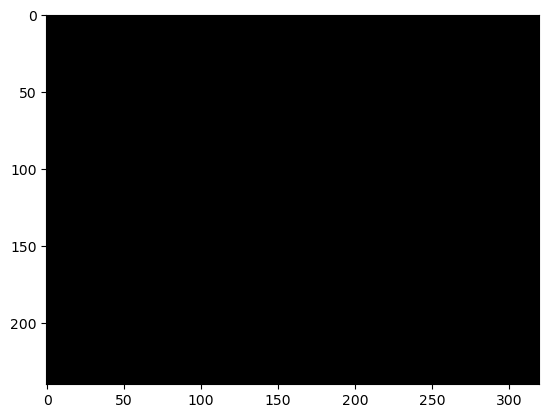

In [6]:
env = gymnasium.make(
    "VizdoomBasic-v1", render_mode="rgb_array", frame_skip=8,
    screen_resolution=vizdoom.ScreenResolution.RES_320X240,
)
obs, *_ = env.reset()
plt.imshow(obs['screen'])
plt.show()

action_names = "wait", "fire", "right", "left"  # must have distinct first tokens
action_map = {tokenizer.vocab[a]: i for i, a in enumerate(action_names)}
assert len(action_map) == len(action_names)
eos_token_ids = list(model.generation_config.eos_token_id)
logits_processor = get_logits_processor(model)
action_history = []
for i in range(100):
    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": obs["screen"]},
            {"type": "text", "text": """
This is a first-person videgame called Doom. Which action should I choose next: `wait`, `fire`, `right`, or `left`? Please use one of these actions, verbatim.
Your shot hits if the enemy is at the center of the screen, **precisely** above the gun barrel, otherwise the shot misses. You aim by moving your point of view left or right. If the enemy is to the right, move right. If it is to the left, move left.
Please analyze the image for only one paragraph, then write "Action: `your_choice`" with one of `wait`, `fire`, `right`, `left`, without quotes, e.g. Action: `wait`.
""".strip()},],},
    ]

    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True, return_dict=True,
        return_tensors="pt", enable_thinking=False
    ).to(model.device)
    
    cache = transformers.DynamicCache(config=model.config)
    with torch.no_grad():
        for i in range(256):
            logits = model(**inputs, use_cache=True, past_key_values=cache).logits[..., -1, :]
            logits = logits_processor(inputs['input_ids'], logits)
            new_token_id = (torch.multinomial(logits.softmax(dim=-1), 1).flatten(
                ) if model.generation_config.do_sample else logits.argmax(-1)).item()
            inputs = dict(input_ids=torch.as_tensor([[new_token_id]], device=model.device))
            new_token = tokenizer.decode(new_token_id)
            print(end=new_token, flush=True)
            if new_token_id in eos_token_ids or '\n' in new_token:
                break  # stop just short of EOS or new paragraph
    print("[reasoning interrupted]")
    finisher_prompt = '''\nAction: `'''
    with torch.no_grad():
        input_ids = tokenizer(finisher_prompt, return_tensors='pt', add_special_tokens=False).to(model.device)['input_ids']
        # v-- do NOT pass attention mask with input_ids when continuing from cache, it breaks the model :S
        scores = model(input_ids, use_cache=True, past_key_values=cache).logits[..., -1, :].softmax(-1).flatten()
    print("Probe top probabilities:")
    for i, cand_i in enumerate((-scores).argsort(-1)[:5].tolist()):
        print(f"#{i} [[{tokenizer.decode(cand_i)}]]: {scores[cand_i]:.5f}")
    assert scores.ndim == 1
    action_token_scores = dict(zip(action_map.keys(), scores[list(action_map.keys())].tolist()))
    action_index = action_map[max(action_token_scores, key=action_token_scores.get)]
    action_history.append(action_index)
    obs, r, done, *_etc = env.step(action_index)
    print("SCORES:", ", ".join(f"{a}: {action_token_scores[tokenizer.vocab[a]]:.5f}" for a in action_names))
    print("ACTION:", action_names[action_index], action_index, f"{r=}, {done=}")
    plt.imshow(obs['screen'])
    plt.show()
    if done:
        break

# Thinking mode

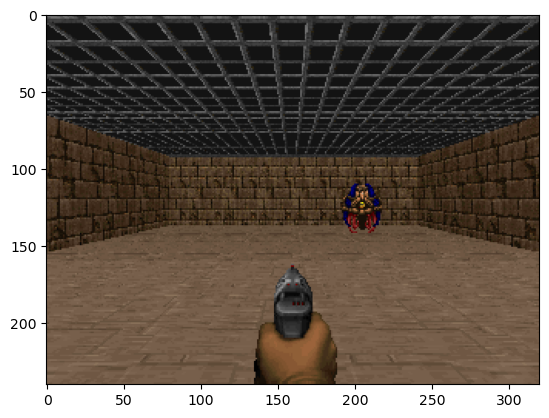

The user wants me to decide the next action in the game Doom.
1.  **Analyze the image:** I see a first-person view of a Doom level. There's a gun in the bottom center. In the distance, slightly to the right of the center, there is an enemy (looks like a demon or monster).
2.  **Evaluate the aiming:** The prompt states: "Your shot hits if the enemy is at the center of the screen, precisely above the gun barrel, otherwise the shot misses. You aim by moving your point of view left or right. If the enemy is to the right, move right. If it is to the left, move left."
3.  **Determine relative position:** The enemy is clearly to the right of the gun barrel's vertical axis. The gun is pointing somewhat towards the center-left, while the enemy is positioned further right in the room.
4.  **Select action:** Since the enemy is to the right, I need to turn right to bring the enemy into the center crosshair/gun barrel alignment. Therefore, the action is `right`.
</think>[reasoning interrupted]
Prob

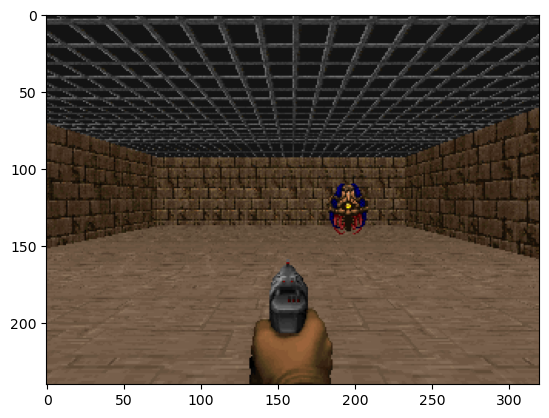

The user wants me to decide on an action in a Doom-like game.
1.  **Analyze the image:**
    *   I see a first-person view of a Doom-like game.
    *   There is a gun (looks like a pistol or shotgun) at the bottom center.
    *   There is an enemy (looks like a Cacodemon or similar floating enemy) in the distance.
    *   The enemy is positioned slightly to the right of the center of the screen, but mostly centered. Wait, let me look closer.
    *   The gun is at the bottom. The enemy is further up.
    *   The enemy is slightly to the right of the vertical center line. The gun barrel is pointing somewhat towards the left of the enemy.
    *   Actually, looking very closely, the gun barrel is pointing at the bottom center. The enemy is located in the upper middle-right area.
    *   The prompt says: "Your shot hits if the enemy is at the center of the screen, **precisely** above the gun barrel, otherwise the shot misses. You aim by moving your point of view left or right. If the enemy 

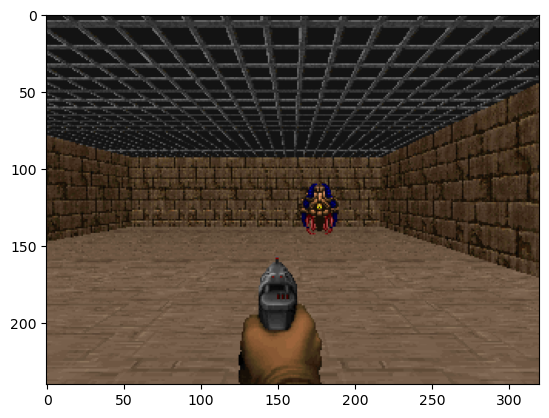

The user wants me to decide on the next action in the game Doom based on the provided image.

[reasoning interrupted]
Probe top probabilities:
#0 [[fire]]: 0.89453
#1 [[right]]: 0.05054
#2 [[wait]]: 0.03467
#3 [[left]]: 0.01855
#4 [[move]]: 0.00008
SCORES: wait: 0.03467, fire: 0.89453, right: 0.05054, left: 0.01855
ACTION: fire 1 r=95.0, done=True


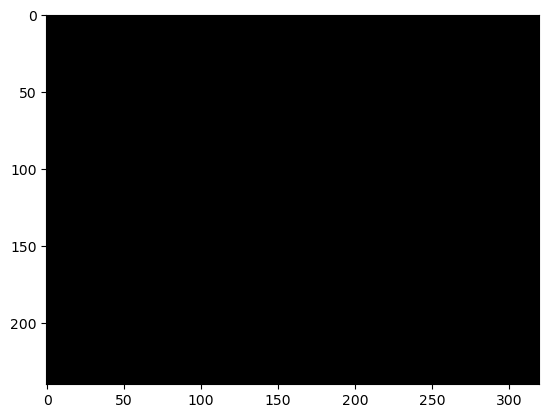

In [7]:
env = gymnasium.make(
    "VizdoomBasic-v1", render_mode="rgb_array", frame_skip=8,
    screen_resolution=vizdoom.ScreenResolution.RES_320X240,
)
obs, *_ = env.reset()
plt.imshow(obs['screen'])
plt.show()

action_names = "wait", "fire", "right", "left"  # must have distinct first tokens
action_map = {tokenizer.vocab[a]: i for i, a in enumerate(action_names)}
assert len(action_map) == len(action_names)
eos_token_ids = list(model.generation_config.eos_token_id)
logits_processor = get_logits_processor(model)
action_history = []
for i in range(100):
    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": obs["screen"]},
            {"type": "text", "text": """
This is a first-person videgame called Doom. Which action should I choose next: `wait`, `fire`, `right`, or `left`? Please use one of these actions, verbatim.
Your private thoughts inside the <think>reasoning block</think> should be a single compressed paragraph because of time constraints. There is no time to double-check or deliberate beyond 1 paragraph.
Your shot hits if the enemy is at the center of the screen, **precisely** above the gun barrel, otherwise the shot misses. You aim by moving your point of view left or right. If the enemy is to the right, move right. If it is to the left, move left.
Please analyze the image for only one paragraph, then write "Action: `your_choice`" with one of `wait`, `fire`, `right`, `left`, without quotes, e.g. Action: `wait`.
""".strip()},],},
    ]

    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True, return_dict=True,
        return_tensors="pt", enable_thinking=True
    ).to(model.device)
    
    cache = transformers.DynamicCache(config=model.config)
    with torch.no_grad():
        for i in range(256):
            logits = model(**inputs, use_cache=True, past_key_values=cache).logits[..., -1, :]
            logits = logits_processor(inputs['input_ids'], logits)
            new_token_id = (torch.multinomial(logits.softmax(dim=-1), 1).flatten(
                ) if model.generation_config.do_sample else logits.argmax(-1)).item()
            inputs = dict(input_ids=torch.as_tensor([[new_token_id]], device=model.device))
            new_token = tokenizer.decode(new_token_id)
            print(end=new_token, flush=True)
            if new_token_id in eos_token_ids or '\n\n' in new_token or '</think>' in new_token:
                break  # stop just short of EOS or new paragraph
    print("[reasoning interrupted]")
    finisher_prompt = '''\n</think>\nAction: `'''
    with torch.no_grad():
        input_ids = tokenizer(finisher_prompt, return_tensors='pt', add_special_tokens=False).to(model.device)['input_ids']
        # v-- do NOT pass attention mask with input_ids when continuing from cache, it breaks the model :S
        scores = model(input_ids, use_cache=True, past_key_values=cache).logits[..., -1, :].softmax(-1).flatten()
    print("Probe top probabilities:")
    for i, cand_i in enumerate((-scores).argsort(-1)[:5].tolist()):
        print(f"#{i} [[{tokenizer.decode(cand_i)}]]: {scores[cand_i]:.5f}")
    assert scores.ndim == 1
    action_token_scores = dict(zip(action_map.keys(), scores[list(action_map.keys())].tolist()))
    action_index = action_map[max(action_token_scores, key=action_token_scores.get)]
    action_history.append(action_index)
    obs, r, done, *_etc = env.step(action_index)
    print("SCORES:", ", ".join(f"{a}: {action_token_scores[tokenizer.vocab[a]]:.5f}" for a in action_names))
    print("ACTION:", action_names[action_index], action_index, f"{r=}, {done=}")
    plt.imshow(obs['screen'])
    plt.show()
    if done:
        break